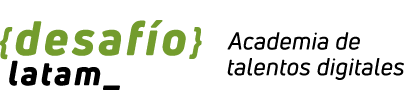

### Desafío: Aprendizaje Supervisado y No Supervisado (Parte II)
#### Predicción de Churn

**Nombre:** Ignacio Robles  
**Generación:** g-115 Data Science – Desafío Latam  

### Introducción
En la industria de las telecomunicaciones, la retención de clientes es un desafío estratégico clave. 
La fuga de clientes (churn) impacta directamente en los ingresos y la sostenibilidad del negocio. 
En este desafío, el objetivo es desarrollar un modelo de machine learning capaz de predecir la probabilidad 
de que un cliente abandone el servicio, utilizando datos históricos y técnicas de análisis, preprocesamiento 
y modelado.

A lo largo de este cuaderno se abordarán las distintas etapas del proceso de ciencia de datos, desde el 
análisis exploratorio hasta la evaluación de modelos predictivos.


---
### 1. Análisis Exploratorio de Datos (EDA)

---

#### Introducción del problema
Antes de construir cualquier modelo predictivo, es fundamental comprender la estructura, distribución y 
características del conjunto de datos. El análisis exploratorio permite identificar patrones, valores nulos, 
outliers y relaciones entre variables que pueden influir en la fuga de clientes.

**Objetivo:** Explorar y comprender el dataset Telco-Customer-Churn para identificar insights relevantes.

---

In [23]:
# Vamos a establecer primero configuraciones generales, la importación de librerías y el seteo visual con pd.set_options

import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    LabelEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# División de datos
from sklearn.model_selection import train_test_split, GridSearchCV

# Modelos de clasificación (mínimo 3 como pide el desafío)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Manejo de advertencias (para que el notebook quede más limpio)
import warnings
warnings.filterwarnings("ignore")


# =========================
# CONFIGURACIÓN DE PANDAS
# (para ver el dataset completo sin cortes)
# =========================

pd.set_option("display.max_columns", None)      # Mostrar todas las columnas
pd.set_option("display.max_rows", None)         # Mostrar todas las filas (útil en muestras pequeñas)
pd.set_option("display.width", None)            # Ajustar ancho automático
pd.set_option("display.max_colwidth", None)     # No cortar el contenido de las celdas
pd.set_option("display.float_format", "{:.4f}".format)  # Formato de decimales
pd.set_option("display.expand_frame_repr", False)

print("Librerías cargadas y configuración de pandas aplicada correctamente.")

Librerías cargadas y configuración de pandas aplicada correctamente.


In [24]:
# Ahora importamos nuestro dataset
df = pd.read_excel('Telco-Customer-Churn.xlsx')

# Ahora imprimimos las 5 primeras filas para revisar que todo esté "ok"
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.8500,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5000,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.1500,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.7500,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.6500,Yes


In [25]:
# Una vez que revisamos que todo ande bien, vamos a realizar un análisis exploratorio con describe e info. Ambos métodos revisan valores estadísticos, tipo de datos 
# y valores nulos.
print("Tipos de datos y valores nulos presentes: ")
print(df.info())
print("\n")
print("Exploración básica de valores estadísticos")
print(df.describe())
print("\n")
print("Exploración de datos únicos")
print(df.nunique())

Tipos de datos y valores nulos presentes: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16 

### Resumen de Limpieza Inicial

1. **Eliminar `customerID`**: Identificador único sin valor predictivo (ruido).
2. **Limpiar `TotalCharges`**: Eliminar las 11 filas con nulos ($<0.2\%$ del total).
3. **Binonizar `Churn`**: Convertir `Yes` $\rightarrow$ `1` y `No` $\rightarrow$ `0`.
4. **Escalar Numéricas**: Normalizar `tenure`, `MonthlyCharges` y `TotalCharges` para balancear magnitudes.

---
### Preprocesamiento de los Datos

---

#### Introducción del problema
Los datos reales suelen contener inconsistencias, valores faltantes y variables categóricas que requieren 
transformación. Un correcto preprocesamiento mejora significativamente el rendimiento de los modelos 
de machine learning.

**Objetivo:** Limpiar, transformar y normalizar las variables según sea necesario.

In [26]:
# Aplicamos un drop column para deshacernos del customerID
df_limpio = df.drop(['customerID'], axis=1).dropna()

df_limpio.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.8500,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5000,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.1500,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.7500,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.6500,Yes


In [27]:
# Creamos nuestra lista con las variabels categóricas que luego usaremos para codificar
categorical_features = [col for col in df_limpio.columns if df_limpio[col].dtype == 'object']

print("Nuestras variables categóricas son: ")
print(categorical_features)

Nuestras variables categóricas son: 
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [28]:
# Instanciamos nuestra clase Label Encoder
label_encoder = LabelEncoder()

# Este cambio lo realizamos para transformar nuestras variables categóricas a valores numéricos (valores que puede procesar y entender nuestro algoritmo)
for feature in categorical_features[:]:
    df_limpio[feature] = label_encoder.fit_transform(df_limpio[feature])

print("Nuestro dataset con variables codificadas")
print(df_limpio.head())

Nuestro dataset con variables codificadas
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  MultipleLines  InternetService  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  PaperlessBilling  PaymentMethod  MonthlyCharges  TotalCharges  Churn
0       0              0        1           0       1             0              1                0               0             2                 0            0            0                0         0                 1              2         29.8500       29.8500      0
1       1              0        0           0      34             1              0                0               2             0                 2            0            0                0         1                 0              3         56.9500     1889.5000      0
2       1              0        0           0       2             1              0                0               2             2                

In [29]:
# Primero separamos nuestras columnas con Standard Scaler
cols_estandarizer = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Instanciamos nuestra clase
scaler = StandardScaler()

# Aplicamos el método fit_transform a las columnas objetivo. Esto lo hacemos para que no haya un peso y nuestro modelo no piense que un valor es más importante que otro
df_limpio[cols_estandarizer] = scaler.fit_transform(df_limpio[cols_estandarizer])

# Revisamos nuestro resultado solo con las columnas a identificar
df_limpio[cols_estandarizer].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.0000,7032.0000,7032.0000
mean,-0.0000,0.0000,-0.0000
std,1.0001,1.0001,1.0001
min,-1.2802,-1.5473,-0.9991
25%,-0.9543,-0.9710,-0.8302
50%,-0.1394,0.1845,-0.3908
75%,0.9199,0.8331,0.6668
max,1.6126,1.7934,2.8243


---
### 3. División del Conjunto de Datos

---
### Introducción del problema
Para evaluar adecuadamente el desempeño de los modelos, es necesario dividir los datos en conjuntos 
de entrenamiento y prueba. Esto permite medir la capacidad de generalización del modelo.

**Objetivo:** Separar los datos en training y testing.

---


In [30]:
# División del dataset en entrenamiento y prueba
X = df_limpio.drop(columns=['Churn'], axis=1)

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,-1.2802,0,1,0,0,2,0,0,0,0,0,1,2,-1.1617,-0.9942
1,1,0,0,0,0.0643,1,0,0,2,0,2,0,0,0,1,0,3,-0.2609,-0.1737
2,1,0,0,0,-1.2395,1,0,0,2,2,0,0,0,0,0,1,3,-0.3639,-0.9596
3,1,0,0,0,0.5125,0,1,0,2,0,2,2,0,0,1,0,0,-0.7479,-0.1952
4,0,0,0,0,-1.2395,1,0,1,0,0,0,0,0,0,0,1,2,0.1962,-0.9405


In [31]:
# Ahora separamos los valores de nuestra variable que funcionará como etiqueta. 
y = df_limpio['Churn']

y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [32]:
# Ahora ocupamos el método train_test_split de Sickit Learn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 4. Entrenamiento de Modelos y Optimización de Hiperparámetros

### Introducción del problema
El uso de múltiples algoritmos permite comparar el desempeño y seleccionar el modelo más adecuado 
para la predicción de churn. Además, la optimización de hiperparámetros ayuda a mejorar la precisión 
y robustez del modelo.

**Objetivo:** Entrenar al menos 3 modelos de clasificación y optimizar sus hiperparámetros.


---
#### 4.1 KNN

---

In [33]:
# Entrenamiento de modelos y optimización de hiperparámetros
# 1. Instanciamos el modelo base
knn = KNeighborsClassifier()

# 2. Definimos una grilla "interesante" y no conservadora
# Exploramos: 
# - n_neighbors: desde muy pocos (sensible a ruido) hasta muchos (suavizado)
# - weights: para dar más valor a los vecinos más cercanos
# - metric: diferentes formas de medir la distancia (Euclidiana vs Manhattan)
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
}

# 3. Configuramos la búsqueda (usando validación cruzada de 5 pliegues)
grid_search = GridSearchCV(
    knn, 
    param_grid, 
    cv=5, 
    scoring='f1', # Usamos F1-score porque en Churn nos importa balancear Precision y Recall
    n_jobs=-1     # Para usar todos los núcleos del procesador
)

# 4. Ajustamos a los datos de entrenamiento
grid_search.fit(X_train, y_train)

# Resultados
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor score (F1): {grid_search.best_score_:.4f}")


Mejores parámetros: {'metric': 'manhattan', 'n_neighbors': 31, 'weights': 'uniform'}
Mejor score (F1): 0.5883


Reporte de Clasificación
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1033
           1       0.58      0.56      0.57       374

    accuracy                           0.78      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.78      0.77      1407



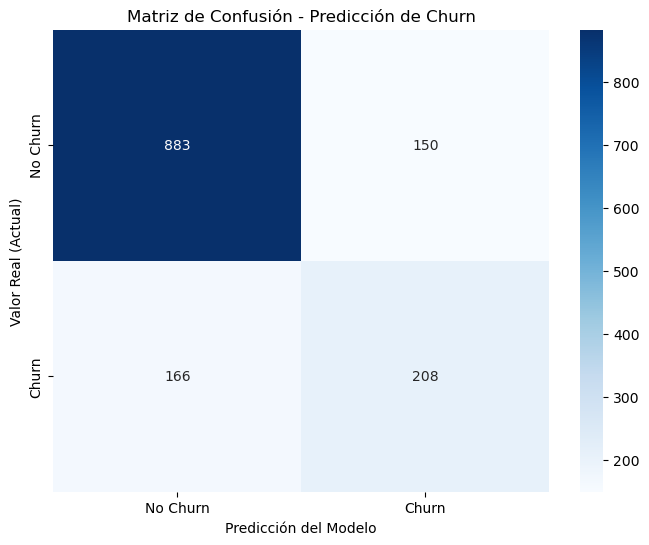

In [34]:
# Ahora que tenemos nuestros hiperparámetros "ganadores", ahora los guardamos en una variable accediendo al atributo de mi objeto
best_knn = grid_search.best_estimator_

# Ahora uso el método predict de mi objeto best_knn
y_pred = best_knn.predict(X_test)

# Finalmente evaluamos nuestros resultados
print("Reporte de Clasificación")
print(classification_report(y_test, y_pred))

# Y el que más me gusta, la matríz de confusión de SNS
cm = confusion_matrix(y_test, y_pred)

# 2. Graficamos con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])

plt.title('Matriz de Confusión - Predicción de Churn')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real (Actual)')
plt.show()

---
### Resumen de Resultados KNN

---
El modelo alcanza un Accuracy del 78%, pero muestra debilidad en la detección de fugas (Churn).

#### Rendimiento por Clase

- **No Churn (0):** Desempeño alto con F1-score de 0.85. El modelo identifica correctamente a la mayoría de los clientes que permanecen en el servicio.  
- **Churn (1):** Desempeño bajo con F1-score de 0.57. Solo captura al 56% (Recall) de los clientes que realmente abandonan el servicio.

#### Hallazgos en la Matriz de Confusión

- **Aciertos:** 883 (No Churn) y 208 (Churn).  
- **Errores:** 166 fugas no detectadas (falsos negativos) y 150 falsas alarmas (falsos positivos).

#### Conclusión

El desbalance de datos (1033 vs 374 casos) afecta significativamente la capacidad del modelo para identificar la clase minoritaria.  
Se recomienda ajustar el umbral de decisión y/o aplicar técnicas de balanceo de clases (como oversampling, undersampling o SMOTE) para mejorar la detección de Churn.

---
### Decision Tree

---

Mejores Parámetros: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 20}

--- Reporte de Clasificación (Árbol) ---
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1033
           1       0.58      0.51      0.54       374

    accuracy                           0.77      1407
   macro avg       0.70      0.69      0.69      1407
weighted avg       0.76      0.77      0.77      1407



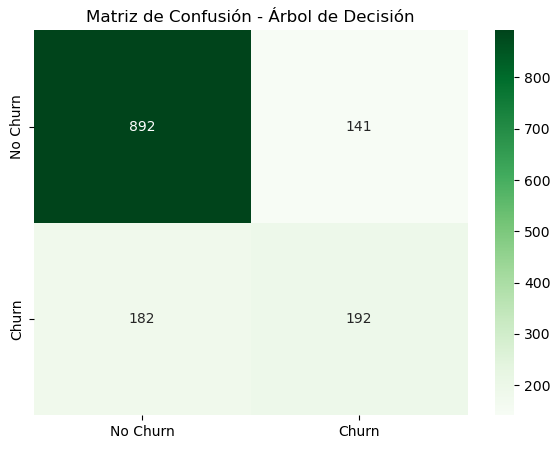

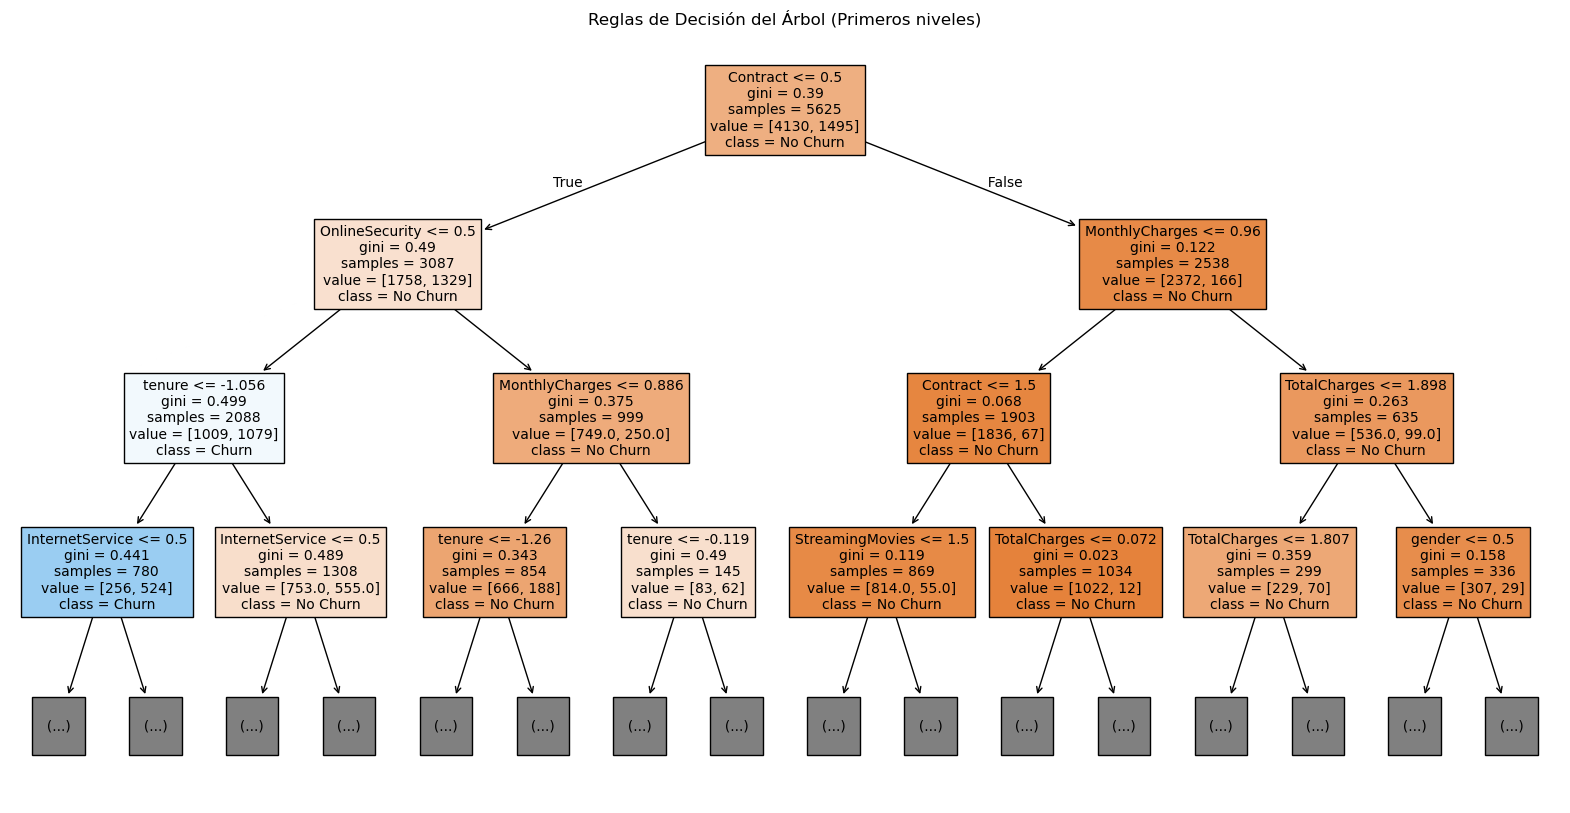

In [35]:
# 1. Instanciamos el modelo
dtree = DecisionTreeClassifier(random_state=42)

# 2. Definimos una grilla para evitar el sobreajuste (overfitting)
# - max_depth: controla qué tan profundo/complejo es el árbol
# - criterion: mide la calidad de la división (Gini o Entropía)
# - min_samples_leaf: evita ramas con muy pocos clientes
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_leaf': [1, 5, 10, 20]
}

# 3. Búsqueda de hiperparámetros
grid_dt = GridSearchCV(dtree, param_grid_dt, cv=5, scoring='f1', n_jobs=-1)
grid_dt.fit(X_train, y_train)

# 4. Extracción del mejor modelo y predicción
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

# 5. Medición de desempeño
print(f"Mejores Parámetros: {grid_dt.best_params_}")
print("\n--- Reporte de Clasificación (Árbol) ---")
print(classification_report(y_test, y_pred_dt))

# 6. Visualización: Matriz de Confusión
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.show()

# 7. Visualización: Estructura del Árbol
# Graficamos solo hasta profundidad 3 para que sea legible
plt.figure(figsize=(20,10))
plot_tree(best_dt, 
          feature_names=X_train.columns, 
          class_names=['No Churn', 'Churn'], 
          filled=True, 
          max_depth=3, 
          fontsize=10)
plt.title('Reglas de Decisión del Árbol (Primeros niveles)')
plt.show()

### Comparativa y Análisis: Árbol de Decisión vs. KNN

El modelo de Árbol de Decisión, configurado con una profundidad máxima de 7 y un mínimo de 20 muestras por hoja, presenta un rendimiento general del 77% de accuracy, ligeramente inferior al KNN (78%) dentro del desarrollo del proyecto del desafío.

#### 1. Rendimiento por Clase

- **No Churn (0):** Mantiene un desempeño sólido con un F1-score de 0.85. El modelo identifica correctamente al 86% de los clientes que no se fugan, mostrando estabilidad en la clase mayoritaria.  
- **Churn (1):** El desempeño es menor en comparación con KNN. El Recall desciende a 0.51 (frente a 0.56 en KNN), lo que indica que el árbol detecta aproximadamente a la mitad de los clientes en riesgo de fuga. La precisión se mantiene en 0.58.

#### 2. Hallazgos en la Matriz de Confusión

- **Falsos Negativos:** 182 casos. El modelo de Árbol de Decisión deja pasar más fugas reales que KNN (166), lo que reduce su capacidad para anticipar el abandono.  
- **Falsos Positivos:** 141 casos. El árbol genera ligeramente menos falsas alarmas que KNN (150), mostrando un comportamiento más conservador en la predicción de churn.

#### 3. Análisis de Reglas de Decisión

A partir de la visualización del árbol, se identifican variables clave que influyen en la predicción de churn dentro del proyecto del desafío:

- **Contract:** Aparece como el nodo raíz (mayor importancia). Los contratos de corta duración, especialmente tipo "Month-to-month", se asocian fuertemente con una mayor probabilidad de fuga.  
- **OnlineSecurity:** La ausencia de este servicio incrementa la probabilidad de churn.  
- **Tenure y MonthlyCharges:** Funcionan como variables de segmentación secundaria; clientes con baja antigüedad y cargos mensuales altos presentan mayor riesgo de abandono.

#### Conclusión

En el contexto de nuestro proyecto del desafío, el Árbol de Decisión aporta interpretabilidad y reglas claras sobre los factores que influyen en la fuga de clientes. Sin embargo, el modelo KNN muestra un mejor desempeño en la detección de churn al capturar un mayor porcentaje de clientes que efectivamente abandonan el servicio.  

Si el objetivo principal es maximizar la detección de fugas, resulta más conveniente priorizar KNN o bien ajustar el peso de clases y los hiperparámetros del Árbol de Decisión para mejorar el recall en la clase minoritaria.

---
### Naive Bayes

---

Mejores Parámetros: {'var_smoothing': 1e-09}

--- Reporte de Clasificación (Naive Bayes) ---
              precision    recall  f1-score   support

           0       0.88      0.74      0.81      1033
           1       0.50      0.73      0.60       374

    accuracy                           0.74      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.74      0.75      1407



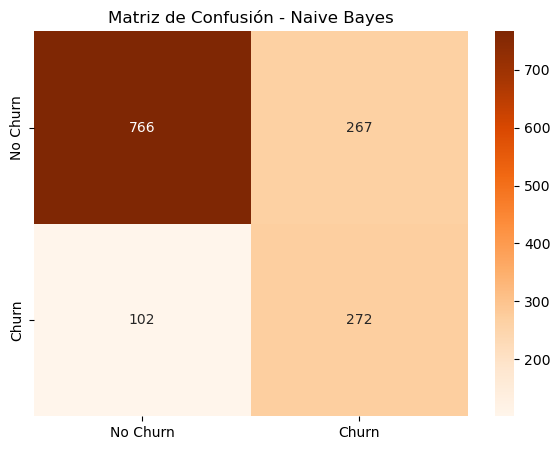

In [37]:
# 1. Instanciamos el modelo
# GaussianNB no tiene muchos hiperparámetros, el principal es var_smoothing
nb = GaussianNB()

# 2. Definimos la grilla
# var_smoothing ayuda a la estabilidad del cálculo cuando las varianzas son muy pequeñas
param_grid_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

# 3. Búsqueda de hiperparámetros
grid_nb = GridSearchCV(nb, param_grid_nb, cv=5, scoring='f1', n_jobs=-1)
grid_nb.fit(X_train, y_train)

# 4. Extracción del mejor modelo y predicción
best_nb = grid_nb.best_estimator_
y_pred_nb = best_nb.predict(X_test)

# 5. Medición de desempeño
print(f"Mejores Parámetros: {grid_nb.best_params_}")
print("\n--- Reporte de Clasificación (Naive Bayes) ---")
print(classification_report(y_test, y_pred_nb))

# 6. Visualización: Matriz de Confusión
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión - Naive Bayes')
plt.show()

## 5. Evaluación del Rendimiento de los Modelos

### Introducción del problema
La evaluación del modelo es clave para determinar su efectividad. Se deben utilizar métricas como 
precisión, recall, F1-score y matriz de confusión para comparar el rendimiento de los distintos modelos.

**Objetivo:** Evaluar y comparar el rendimiento de los modelos utilizando métricas pertinentes.


---
### Análisis de Resultados: Gaussian Naive Bayes

---

El modelo Gaussian Naive Bayes presenta un comportamiento distinto al de los modelos anteriores, priorizando la detección de fugas por sobre la precisión global, alcanzando un Accuracy del 74% en el desarrollo del proyecto del desafío.

#### 1. Rendimiento por Clase

- **No Churn (0):** El rendimiento disminuye en comparación con los otros modelos. Un Recall de 0.74 indica que el modelo deja de identificar correctamente a un 26% de los clientes estables, clasificándolos erróneamente como posibles fugas.  
- **Churn (1):** Este es el principal punto fuerte del modelo. Alcanza un Recall de 0.73, superando de forma clara a KNN (0.56) y al Árbol de Decisión (0.51). No obstante, su Precisión de 0.50 es baja, lo que implica que aproximadamente la mitad de las alertas de fuga corresponden a falsas alarmas.

#### 2. Hallazgos en la Matriz de Confusión

- **Verdaderos Positivos (Churn):** 272 casos correctamente detectados, siendo el modelo que más clientes en riesgo logra identificar dentro del proyecto.  
- **Falsos Negativos:** 102 casos, reduciendo considerablemente el riesgo de no detectar clientes que efectivamente abandonan el servicio en comparación con los modelos previos.  
- **Falsos Positivos:** 267 casos, lo que genera un mayor volumen de falsas alarmas y, por tanto, un aumento en el ruido operativo.

#### 3. Conclusión

En el contexto de nuestro proyecto del desafío, Gaussian Naive Bayes se posiciona como el modelo más conservador y orientado a la prevención. Aunque presenta el Accuracy más bajo, su alta capacidad para detectar clientes en riesgo de fuga (Recall de 0.73) lo convierte en una alternativa valiosa cuando la prioridad es anticipar el churn.  

Este comportamiento sugiere que el modelo es especialmente útil en escenarios donde el costo de perder un cliente es mayor que el costo de aplicar acciones de retención innecesarias, aceptando un mayor número de falsas alarmas a cambio de reducir las fugas no detectadas.

---
#### Análisis de Resultados: Gaussian Naive Bayes
---

El modelo Gaussian Naive Bayes presenta un comportamiento distinto al de los modelos anteriores, priorizando la detección de fugas por sobre la precisión global, alcanzando un Accuracy del 74% en el desarrollo del proyecto del desafío.

#### 1. Rendimiento por Clase

- **No Churn (0):** El rendimiento disminuye en comparación con los otros modelos. Un Recall de 0.74 indica que el modelo deja de identificar correctamente a un 26% de los clientes estables, clasificándolos erróneamente como posibles fugas.  
- **Churn (1):** Este es el principal punto fuerte del modelo. Alcanza un Recall de 0.73, superando de forma clara a KNN (0.56) y al Árbol de Decisión (0.51). No obstante, su Precisión de 0.50 es baja, lo que implica que aproximadamente la mitad de las alertas de fuga corresponden a falsas alarmas.

#### 2. Hallazgos en la Matriz de Confusión

- **Verdaderos Positivos (Churn):** 272 casos correctamente detectados, siendo el modelo que más clientes en riesgo logra identificar dentro del proyecto.  
- **Falsos Negativos:** 102 casos, reduciendo considerablemente el riesgo de no detectar clientes que efectivamente abandonan el servicio en comparación con los modelos previos.  
- **Falsos Positivos:** 267 casos, lo que genera un mayor volumen de falsas alarmas y, por tanto, un aumento en el ruido operativo.

#### 3. Conclusión

En el contexto de nuestro proyecto del desafío, Gaussian Naive Bayes se posiciona como el modelo más conservador y orientado a la prevención. Aunque presenta el Accuracy más bajo, su alta capacidad para detectar clientes en riesgo de fuga (Recall de 0.73) lo convierte en una alternativa valiosa cuando la prioridad es anticipar el churn.  

Este comportamiento sugiere que el modelo es especialmente útil en escenarios donde el costo de perder un cliente es mayor que el costo de aplicar acciones de retención innecesarias, aceptando un mayor número de falsas alarmas a cambio de reducir las fugas no detectadas.

---
## Agradecimientos

Gracias por la oportunidad de desarrollar este desafío de aprendizaje.  
A seguir aprendiendo y creciendo en el camino de Data Science.
